In [1]:
!pip install -q "trl==1.4.0" peft bitsandbytes accelerate datasets
import torch
import pandas as pd
import numpy as np
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig
from sklearn.metrics import classification_report, f1_score, accuracy_score
import time, json, warnings, os
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Cihaz   : {device}")


Cihaz   : cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')
!ls -la /content/drive/MyDrive/bdm_proje/data/raw/

Mounted at /content/drive
total 134
-rw------- 1 root root 137196 May 25 11:33 data.csv


In [3]:
LABEL_NAMES = {
    0: "Yardım Talebi",
    1: "Kayıp Bildirimi",
    2: "Altyapı Hasarı",
    3: "Bağış/Koordinasyon",
    4: "Diğer/İlgisiz"
}

train_df = pd.read_csv('/content/drive/MyDrive/bdm_proje/data/processed/train.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/bdm_proje/data/processed/val.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/bdm_proje/data/processed/test.csv')

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")
print(f"\nTrain etiket dağılımı:")
print(train_df['label_id'].value_counts().sort_index())

Train : 633
Val   : 80
Test  : 80

Train etiket dağılımı:
label_id
0    231
1     78
2     80
3     83
4    161
Name: count, dtype: int64


In [4]:
MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# ============================================================
# 4-BIT QUANTIZATION AYARI
# ============================================================
# nf4 → "Normal Float 4" — QLoRA makalesi tarafından önerilen format
# double_quant → quantization parametrelerini de quantize eder, ekstra bellek tasarrufu
bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_quant_type       = "nf4",
    bnb_4bit_compute_dtype    = torch.float16,
    bnb_4bit_use_double_quant = True
)

print("Model yükleniyor (4-bit QLoRA)...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"  # eğitimde sağdan padding

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config = bnb_config,
    device_map          = "auto"
)

# Gradient checkpoint — VRAM daha da düşer, biraz yavaşlar ama güvenli
model.gradient_checkpointing_enable()
model.config.use_cache = False  # gradient checkpoint ile uyumsuz, kapatıyoruz

print(f"✅ Model yüklendi!")
print(f"VRAM kullanımı: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Model yükleniyor (4-bit QLoRA)...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Model yüklendi!
VRAM kullanımı: 0.78 GB


In [9]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_quant_type       = "nf4",
    bnb_4bit_compute_dtype    = torch.float16,   # T4 → fp16
    bnb_4bit_use_double_quant = True,
)

# Modeli fp16 olarak YENİDEN yükle (eski 'model' üzerine yazılır)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config = bnb_config,
    device_map          = "auto",
    dtype               = torch.float16,
)
model.config.use_cache = False

# KRİTİK — notebook'ta eksikti: k-bit eğitim hazırlığı (gradient checkpointing'i de açar)
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

lora_config = LoraConfig(
    r              = 16,
    lora_alpha     = 32,
    target_modules = ["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout   = 0.05,
    bias           = "none",
    task_type      = TaskType.CAUSAL_LM,
)
model = get_peft_model(model, lora_config)

# LoRA gradyanlarını fp32'ye sabitle → fp16 GradScaler bf16'yı kabul etmiyordu
for p in model.parameters():
    if p.requires_grad:
        p.data = p.data.float()

egitilen = sum(p.numel() for p in model.parameters() if p.requires_grad)
toplam   = sum(p.numel() for p in model.parameters())
print(f"✅ Model hazır — eğitilen {egitilen/1e6:.2f}M (%{egitilen/toplam*100:.2f})")
print("Trainable dtype:", {str(p.dtype) for p in model.parameters() if p.requires_grad})

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model hazır — eğitilen 4.51M (%0.73)
Trainable dtype: {'torch.float32'}


In [10]:
def format_prompt(row):
    """
    Her tweet'i instruction-following formatına çevirir.
    Model bu formatta hem soruyu hem cevabı görür — böyle öğrenir.
    """
    sistem = (
        "Sen bir deprem acil durum sınıflandırma asistanısın. "
        "Verilen tweeti aşağıdaki kategorilerden birine koy. "
        "SADECE kategori adını yaz, başka hiçbir şey yazma."
    )

    kullanici = (
        f"Tweet: {row['tweet']}\n\n"
        "Kategoriler:\n"
        "- Yardım Talebi\n"
        "- Kayıp Bildirimi\n"
        "- Altyapı Hasarı\n"
        "- Bağış/Koordinasyon\n"
        "- Diğer/İlgisiz\n\n"
        "Kategori:"
    )

    asistan = LABEL_NAMES[row['label_id']]

    # TinyLlama chat formatı
    return (
        f"<|system|>\n{sistem}</s>\n"
        f"<|user|>\n{kullanici}</s>\n"
        f"<|assistant|>\n{asistan}</s>"
    )


# Tüm setlere uygula
train_df['prompt'] = train_df.apply(format_prompt, axis=1)
val_df['prompt']   = val_df.apply(format_prompt, axis=1)

# Örnek göster
print("=== ÖRNEK PROMPT ===")
print(train_df['prompt'].iloc[0])
print(f"\nOrtalama token uzunluğu: {train_df['prompt'].apply(lambda x: len(x.split())).mean():.0f} kelime")

=== ÖRNEK PROMPT ===
<|system|>
Sen bir deprem acil durum sınıflandırma asistanısın. Verilen tweeti aşağıdaki kategorilerden birine koy. SADECE kategori adını yaz, başka hiçbir şey yazma.</s>
<|user|>
Tweet: Beyoğlu mahallesi, şehit İsmail Orçan bulvarı no:32 Türkoğlu / Kahramanmaraş +905388623929  Tanju Ulu  Acil çadır desteğine ihtiyaç vardır. Yardımcı olun lütfen. Belirtilen adrese yardım gitmemiş. Güncel bilgidir. İletişim halindeyiz.

Kategoriler:
- Yardım Talebi
- Kayıp Bildirimi
- Altyapı Hasarı
- Bağış/Koordinasyon
- Diğer/İlgisiz

Kategori:</s>
<|assistant|>
Yardım Talebi</s>

Ortalama token uzunluğu: 63 kelime


In [11]:
from datasets import Dataset

# trl 1.4.0 → 'prompt' + 'completion' formatı bekliyor
def format_prompt_completion(row):
    sistem = (
        "Sen bir deprem acil durum sınıflandırma asistanısın. "
        "Verilen tweeti aşağıdaki kategorilerden birine koy. "
        "SADECE kategori adını yaz, başka hiçbir şey yazma."
    )
    kullanici = (
        f"Tweet: {row['tweet']}\n\n"
        "Kategoriler:\n"
        "- Yardım Talebi\n"
        "- Kayıp Bildirimi\n"
        "- Altyapı Hasarı\n"
        "- Bağış/Koordinasyon\n"
        "- Diğer/İlgisiz\n\n"
        "Kategori:"
    )
    prompt = (
        f"<|system|>\n{sistem}</s>\n"
        f"<|user|>\n{kullanici}</s>\n"
        f"<|assistant|>\n"
    )
    completion = f"{LABEL_NAMES[row['label_id']]}</s>"

    return {"prompt": prompt, "completion": completion}

train_rows = [format_prompt_completion(row) for _, row in train_df.iterrows()]
val_rows   = [format_prompt_completion(row) for _, row in val_df.iterrows()]

train_dataset = Dataset.from_list(train_rows)
val_dataset   = Dataset.from_list(val_rows)

print(f"Train: {len(train_dataset)}")
print(f"Val  : {len(val_dataset)}")
print(f"\nÖrnek:")
print(f"PROMPT     : {train_dataset[0]['prompt'][:100]}...")
print(f"COMPLETION : {train_dataset[0]['completion']}")

Train: 633
Val  : 80

Örnek:
PROMPT     : <|system|>
Sen bir deprem acil durum sınıflandırma asistanısın. Verilen tweeti aşağıdaki kategoriler...
COMPLETION : Yardım Talebi</s>


In [15]:
import torch, os, gc
from transformers import (AutoModelForCausalLM, AutoTokenizer,
                          BitsAndBytesConfig, EarlyStoppingCallback)
from peft import (LoraConfig, get_peft_model,
                  prepare_model_for_kbit_training, TaskType)
from trl import SFTTrainer, SFTConfig

try: del model, trainer
except: pass
gc.collect(); torch.cuda.empty_cache()

MODEL_ID   = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
OUTPUT_DIR = "/content/drive/MyDrive/bdm_proje/models/tinyllama_qlora"
os.makedirs(OUTPUT_DIR, exist_ok=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Her şey bf16 → GradScaler yok, bf16 grad hatası yok
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, device_map="auto", dtype=torch.bfloat16,
)
model.config.use_cache = False

model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
model = get_peft_model(model, LoraConfig(
    r=16, lora_alpha=32, target_modules=["q_proj","v_proj","k_proj","o_proj"],
    lora_dropout=0.05, bias="none", task_type=TaskType.CAUSAL_LM,
))
model.print_trainable_parameters()

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4, per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4, weight_decay=0.01, warmup_ratio=0.03, lr_scheduler_type="cosine",
    eval_strategy="steps", eval_steps=50,
    save_strategy="steps", save_steps=50, save_total_limit=2,
    load_best_model_at_end=True, metric_for_best_model="eval_loss",
    logging_steps=10, report_to="none",
    completion_only_loss=True, seed=SEED,
    fp16=False, bf16=True,     # <<< KRİTİK: bf16 modu, GradScaler devre dışı
)
trainer = SFTTrainer(
    model=model, train_dataset=train_dataset, eval_dataset=val_dataset,
    args=sft_config, processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Eğitim başlıyor...\n")
train_result    = trainer.train()
train_runtime_s = train_result.metrics['train_runtime']
gpu_mem_gb      = torch.cuda.max_memory_allocated() / 1e9
print(f"\n✅ Tamamlandı! Loss={train_result.training_loss:.4f} | "
      f"Süre={train_runtime_s:.0f}s | Peak GPU={gpu_mem_gb:.2f}GB")

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"✅ Adaptör kaydedildi: {OUTPUT_DIR}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


Adding EOS to train dataset:   0%|          | 0/633 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/633 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/80 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Eğitim başlıyor...



Step,Training Loss,Validation Loss
50,0.044314,0.060827
100,0.009582,0.036035



✅ Tamamlandı! Loss=0.1097 | Süre=1697s | Peak GPU=3.29GB
✅ Adaptör kaydedildi: /content/drive/MyDrive/bdm_proje/models/tinyllama_qlora


In [16]:
import trl
print(trl.__version__)

1.4.0


In [17]:
# =====================================================================
# DEĞERLENDIRME — test setinde tahmin, metrikler, confusion matrix, hata analizi
# =====================================================================
import time
import numpy as np
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

# Çıkarım için cache'i aç (eğitimde kapalıydı)
model.config.use_cache = True
model.eval()

def build_eval_prompt(tweet):
    sistem = ("Sen bir deprem acil durum sınıflandırma asistanısın. "
              "Verilen tweeti aşağıdaki kategorilerden birine koy. "
              "SADECE kategori adını yaz, başka hiçbir şey yazma.")
    kullanici = (f"Tweet: {tweet}\n\n"
                 "Kategoriler:\n"
                 "- Yardım Talebi\n- Kayıp Bildirimi\n- Altyapı Hasarı\n"
                 "- Bağış/Koordinasyon\n- Diğer/İlgisiz\n\n"
                 "Kategori:")
    return (f"<|system|>\n{sistem}</s>\n"
            f"<|user|>\n{kullanici}</s>\n"
            f"<|assistant|>\n")

def parse_label(text):
    t = text.lower()
    if "yardım" in t or "yardim" in t:                      return 0
    if "kayıp" in t or "kayip" in t:                        return 1
    if "altyapı" in t or "altyapi" in t:                    return 2
    if "bağış" in t or "bagis" in t or "koordinasyon" in t: return 3
    if "diğer" in t or "diger" in t or "ilgisiz" in t:      return 4
    return -1

print(f"Test setinde değerlendirme: {len(test_df)} tweet\n")

preds, trues, latencies, rows = [], [], [], []
for _, row in test_df.iterrows():
    prompt = build_eval_prompt(row['tweet'])
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    in_len = inputs['input_ids'].shape[1]

    t0 = time.time()
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=12, do_sample=False,
                             pad_token_id=tokenizer.eos_token_id)
    latencies.append((time.time() - t0) * 1000)

    gen = tokenizer.decode(out[0][in_len:], skip_special_tokens=True).strip()
    pid = parse_label(gen)
    pred = pid if pid != -1 else 4   # parse edilemezse Diğer'e düş

    gercek = int(row['label_id'])
    preds.append(pred); trues.append(gercek)
    rows.append({
        'tweet'      : row['tweet'],
        'gercek'     : gercek,
        'gercek_ad'  : LABEL_NAMES[gercek],
        'model_yanit': gen,
        'tahmin'     : pred,
        'tahmin_ad'  : LABEL_NAMES[pred],
        'parse_fail' : pid == -1,
        'dogru_mu'   : pred == gercek
    })

acc = accuracy_score(trues, preds)
mf1 = f1_score(trues, preds, average='macro',    zero_division=0)
wf1 = f1_score(trues, preds, average='weighted', zero_division=0)

print("=" * 55)
print("TinyLlama-1.1B — QLoRA FINE-TUNED SONUÇLARI")
print("=" * 55)
print(f"Accuracy       : {acc:.4f}  ({acc*100:.1f}%)")
print(f"Macro-F1       : {mf1:.4f}")
print(f"Weighted-F1    : {wf1:.4f}")
print(f"Inference      : {np.mean(latencies):.1f} ms/tweet")
print(f"Parse başarısız: {sum(r['parse_fail'] for r in rows)} / {len(rows)}")
print()
print(classification_report(
    trues, preds,
    labels=[0,1,2,3,4],
    target_names=[LABEL_NAMES[i] for i in range(5)],
    zero_division=0))

cm = confusion_matrix(trues, preds, labels=[0,1,2,3,4])
print("\nConfusion Matrix (satır=gerçek, sütun=tahmin):")
print(cm)

Test setinde değerlendirme: 80 tweet

TinyLlama-1.1B — QLoRA FINE-TUNED SONUÇLARI
Accuracy       : 0.9250  (92.5%)
Macro-F1       : 0.9082
Weighted-F1    : 0.9210
Inference      : 960.5 ms/tweet
Parse başarısız: 0 / 80

                    precision    recall  f1-score   support

     Yardım Talebi       0.93      0.97      0.95        29
   Kayıp Bildirimi       0.91      1.00      0.95        10
    Altyapı Hasarı       0.91      1.00      0.95        10
Bağış/Koordinasyon       0.88      0.64      0.74        11
     Diğer/İlgisiz       0.95      0.95      0.95        20

          accuracy                           0.93        80
         macro avg       0.92      0.91      0.91        80
      weighted avg       0.92      0.93      0.92        80


Confusion Matrix (satır=gerçek, sütun=tahmin):
[[28  0  0  0  1]
 [ 0 10  0  0  0]
 [ 0  0 10  0  0]
 [ 2  1  1  7  0]
 [ 0  0  0  1 19]]


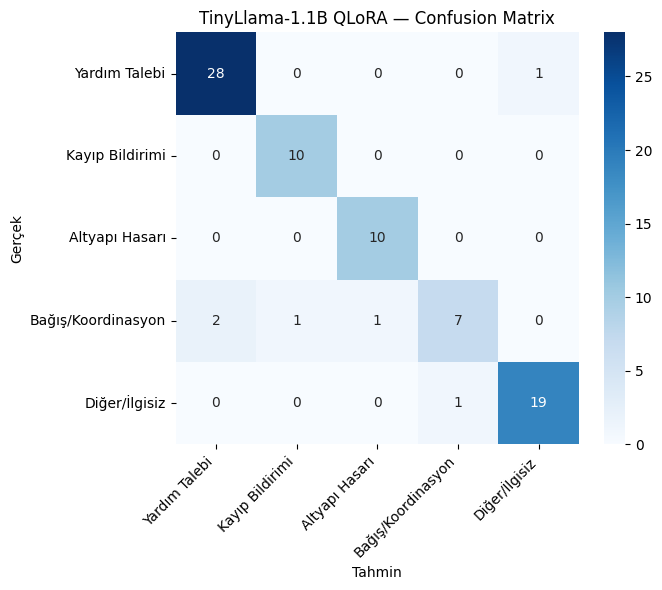

✅ Kaydedildi → /content/drive/MyDrive/bdm_proje/results/fine_tuned
   • tinyllama_qlora_sonuc.json   (metrikler)
   • tinyllama_qlora_hatalar.csv  (6 hatalı örnek)
   • tinyllama_qlora_cm.png       (confusion matrix)


In [18]:
# =====================================================================
# SONUÇLARI KAYDET — results/fine_tuned/  (rapor + sunum buradan beslenecek)
# =====================================================================
import json, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

out_dir = '/content/drive/MyDrive/bdm_proje/results/fine_tuned'
os.makedirs(out_dir, exist_ok=True)

# 1) Metrik özeti JSON
sonuc = {
    "model"          : "TinyLlama-1.1B-Chat-v1.0",
    "model_id"       : "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "parametre"      : "1.1B",
    "yontem"         : "QLoRA (4-bit NF4, fp16)",
    "seed"           : SEED,
    "test_size"      : int(len(test_df)),
    "accuracy"       : round(float(acc), 4),
    "f1_macro"       : round(float(mf1), 4),
    "f1_weighted"    : round(float(wf1), 4),
    "inference_ms"   : round(float(np.mean(latencies)), 1),
    "egitim_suresi_s": round(float(train_runtime_s), 0),
    "peak_gpu_gb"    : round(float(gpu_mem_gb), 2),
    "egitilen_param" : int(sum(p.numel() for p in model.parameters() if p.requires_grad)),
    "parse_basarisiz": int(sum(r['parse_fail'] for r in rows)),
    "confusion_matrix": cm.tolist(),
    "classification_report": classification_report(
        trues, preds, labels=[0,1,2,3,4],
        target_names=[LABEL_NAMES[i] for i in range(5)],
        zero_division=0, output_dict=True)
}
with open(os.path.join(out_dir, 'tinyllama_qlora_sonuc.json'), 'w', encoding='utf-8') as f:
    json.dump(sonuc, f, ensure_ascii=False, indent=2)

# 2) Hata örnekleri CSV (hocanın istediği "en az 5 hatalı örnek")
df_rows = pd.DataFrame(rows)
df_err  = df_rows[df_rows['dogru_mu'] == False]
df_err.to_csv(os.path.join(out_dir, 'tinyllama_qlora_hatalar.csv'),
              index=False, encoding='utf-8')

# 3) Confusion matrix görseli
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[LABEL_NAMES[i] for i in range(5)],
            yticklabels=[LABEL_NAMES[i] for i in range(5)])
plt.xlabel('Tahmin'); plt.ylabel('Gerçek')
plt.title('TinyLlama-1.1B QLoRA — Confusion Matrix')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'tinyllama_qlora_cm.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Kaydedildi → {out_dir}")
print(f"   • tinyllama_qlora_sonuc.json   (metrikler)")
print(f"   • tinyllama_qlora_hatalar.csv  ({len(df_err)} hatalı örnek)")
print(f"   • tinyllama_qlora_cm.png       (confusion matrix)")